In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 1. Load the data
data_file = 'LEGO Analytics Case Data.xlsx'
df = pd.read_excel(data_file)

In [19]:
# 2. Inspect and clean column names
print("Original columns:", df.columns.tolist())

#Rename columns for consistency
df = df.rename(columns={
    'Set #': 'SetID',
    'Piece Count': 'PieceCount',
    '# of Minifigures': 'Minifigures',
    'US Retail Price ($)': 'Price'
})

Original columns: ['SetID', 'Name', 'Theme', 'Subtheme', 'Release Month (US)', 'PieceCount', 'Minifigures', 'Length (in.)', 'Width (in.)', 'Height (in.)', 'Weight (lb.)', 'Price', 'price_per_piece']


In [28]:
# 3. Compute price-per-piece
df['price_per_piece'] = df['Price'] / df['PieceCount']

In [29]:
# 4. Define themes and subthemes
themes = [
  'Architecture','City','Creator','Creator Expert','DC Super Heroes','Disney',
  'Friends','Harry Potter','Hidden Side','Ideas','Jurassic World','LEGO Movie 2',
  'Marvel Super Heroes','Minecraft','Ninjago','Speed Champions','Star Wars','Technic'
]
subthemes = ['Brickheadz', 'Juniors']

In [30]:
# 5. Filter data
df_theme = df[df['Theme'].isin(themes)].copy()
df_sub = df[df['Subtheme'].isin(subthemes)].copy()

In [32]:
# 6. Descriptive summaries
theme_summary = df_theme.groupby('Theme').agg(
    set_count=('SetID', 'count'),
    avg_pieces=('PieceCount', 'mean'),
    avg_price=('Price', 'mean'),
    avg_price_per_piece=('price_per_piece', 'mean')
).reset_index()
sub_summary = df_sub.groupby('Subtheme').agg(
    set_count=('SetID', 'count'),
    avg_pieces=('PieceCount', 'mean'),
    avg_price=('Price', 'mean'),
    avg_price_per_piece=('price_per_piece', 'mean')
).reset_index()
print(theme_summary)
print(sub_summary)

                  Theme  set_count   avg_pieces   avg_price  \
0          Architecture          8   939.000000   72.490000   
1                  City         66   339.969697   47.702121   
2               Creator         26   353.884615   32.413077   
3        Creator Expert         10  1751.300000  164.990000   
4       DC Super Heroes         25   365.120000   37.790000   
5                Disney         30   305.600000   38.990000   
6               Friends         63   305.333333   31.021746   
7          Harry Potter         20   693.000000   59.490000   
8           Hidden Side          8   585.875000   54.990000   
9                 Ideas          9  1209.666667   91.656667   
10       Jurassic World         17   531.588235   61.460588   
11         LEGO Movie 2         30   502.500000   51.156667   
12  Marvel Super Heroes         33   351.939394   35.899091   
13            Minecraft         19   309.631579   31.305789   
14              Ninjago         41   531.073171   45.47

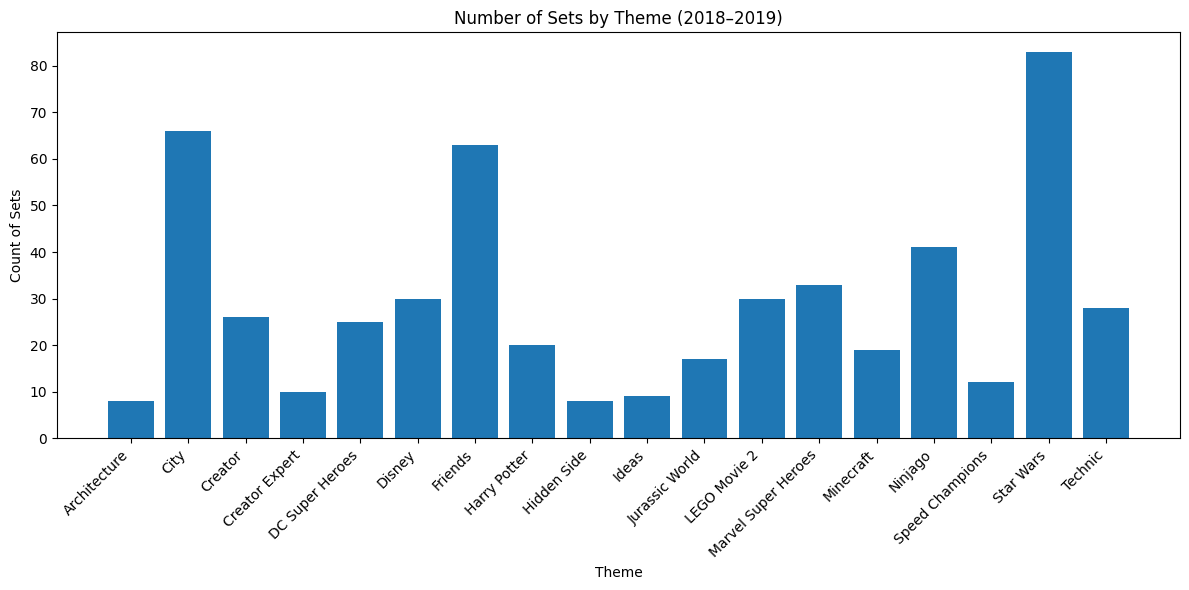

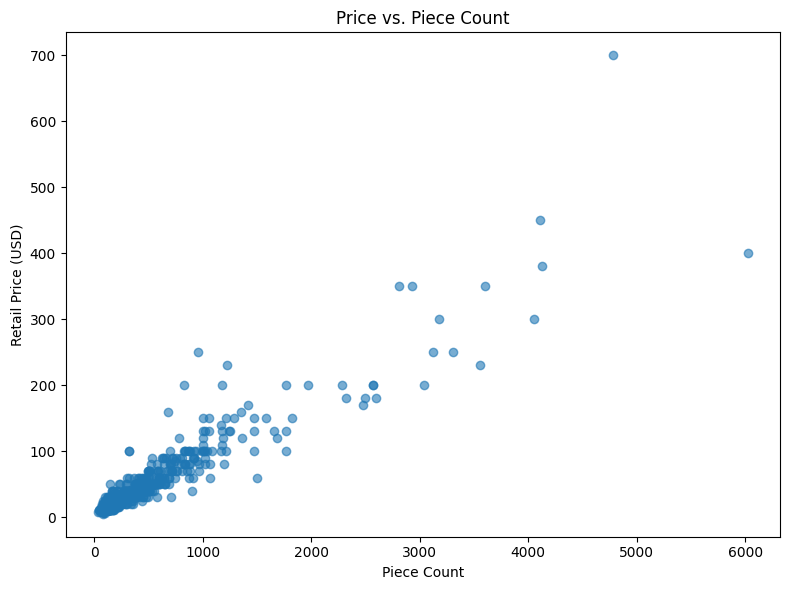

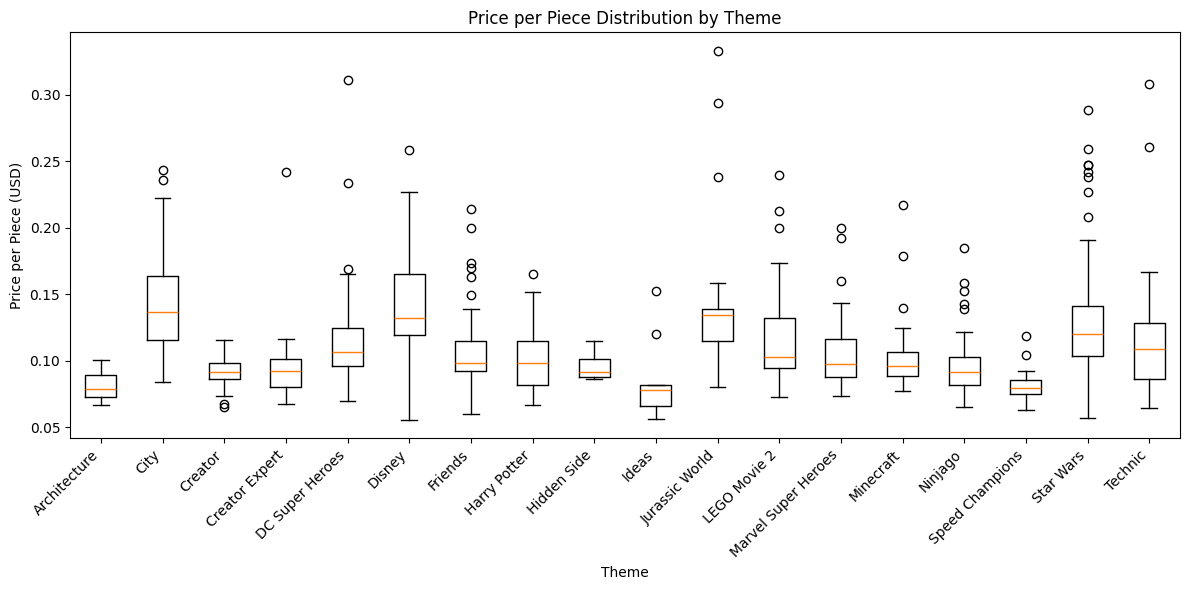

In [35]:
# 7. Visualizations

# a) Number of sets by theme
plt.figure(figsize=(12,6))
plt.bar(theme_summary['Theme'], theme_summary['set_count'])
plt.title('Number of Sets by Theme (2018–2019)')
plt.xlabel('Theme')
plt.ylabel('Count of Sets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('sets_by_theme.png')
plt.show()
plt.close()

# b) Price vs. Piece Count scatter
plt.figure(figsize=(8,6))
plt.scatter(df['PieceCount'], df['Price'], alpha=0.6)
plt.title('Price vs. Piece Count')
plt.xlabel('Piece Count')
plt.ylabel('Retail Price (USD)')
plt.tight_layout()
plt.savefig('price_vs_pieces.png')
plt.show()
plt.close()

# c) Price-per-Piece boxplot by theme
plt.figure(figsize=(12,6))
box_data = [df_theme[df_theme['Theme']==t]['price_per_piece'] for t in themes]
plt.boxplot(box_data)
plt.xticks(ticks=range(1,len(themes)+1), labels=themes, rotation=45, ha='right')
plt.title('Price per Piece Distribution by Theme')
plt.xlabel('Theme')
plt.ylabel('Price per Piece (USD)')
plt.tight_layout()
plt.savefig('price_per_piece_by_theme.png')
plt.show()
plt.close()

In [36]:
# 8. Export summaries to CSV
theme_summary.to_csv('theme_summary.csv', index=False)
sub_summary.to_csv('subtheme_summary.csv', index=False)